In [28]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

df = pd.read_csv("salary.txt", delim_whitespace=True)
df.head()


/var/folders/4c/hyv6qz1537z47z1zpjs7r47r0000gn/T/ipykernel_8134/3128174666.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("salary.txt", delim_whitespace=True)


,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.0


In [29]:
print(df["yrdeg"].min())
print(df["yrdeg"].max())
df["yrdeg"] = 1900 + df["yrdeg"]
df.head()

48
96


,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,1992,Other,95,95,Assist,0,6684.0
1,2,2,M,Other,1991,Other,94,94,Assist,0,4743.0
2,3,2,M,Other,1991,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,1996,Other,95,95,Assist,0,4231.0
4,5,6,M,PhD,1966,Other,91,91,Full,1,11182.0


In [30]:
## We just want unique entries,so we group them by IDs and select only the first entry
df1 = (df.sort_values(["id", "year"])
         .groupby("id", as_index=False)
         .agg(sex=("sex", "first"),
              yrdeg=("yrdeg", "first")))
df1.head()

,id,sex,yrdeg
0,1,F,1992
1,2,M,1991
2,4,M,1996
3,6,M,1966
4,7,M,1970


In [31]:
df1.isna().sum()
#No NA values

id       0
sex      0
yrdeg    0
dtype: int64

In [32]:
male = df1.loc[df1.sex == "M", "yrdeg"]
female = df1.loc[df1.sex == "F", "yrdeg"]

print("Male n:", len(male))
print("Female n:", len(female))


Male n: 1188
Female n: 409


In [33]:
male_mean = male.mean()
female_mean = female.mean()

male_median = male.median()
female_median = female.median()

print("Male mean yrdeg:", male_mean)
print("Female mean yrdeg:", female_mean)

print("Difference in means (M - F):", male_mean - female_mean)

Male mean yrdeg: 1974.3686868686868
Female mean yrdeg: 1981.1075794621026
Difference in means (M - F): -6.738892593415812


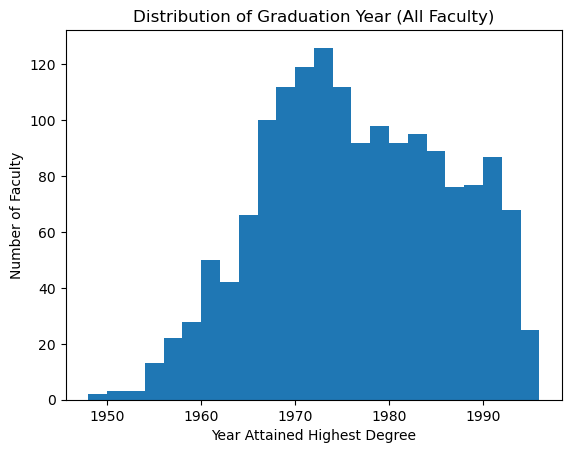

In [34]:

plt.figure()
bins = np.arange(df1["yrdeg"].min(), df1["yrdeg"].max() + 2, 2)

plt.hist(df1["yrdeg"], bins=bins)

plt.xlabel("Year Attained Highest Degree")
plt.ylabel("Number of Faculty")
plt.title("Distribution of Graduation Year (All Faculty)")

plt.show()


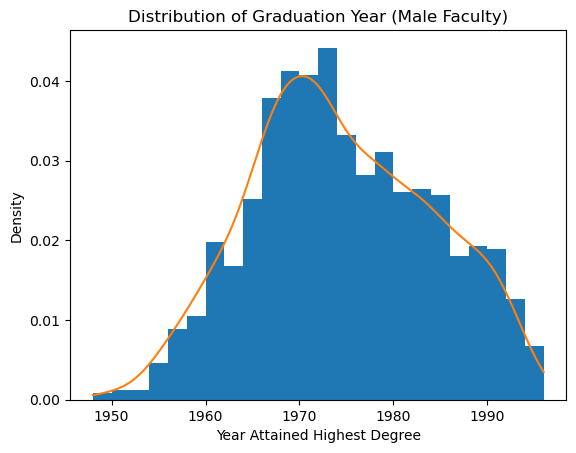

In [35]:



plt.figure()


plt.hist(male, bins=bins, density=True)
kde = gaussian_kde(male)
x_vals = np.linspace(male.min(), male.max(), 500)
plt.plot(x_vals, kde(x_vals))

plt.xlabel("Year Attained Highest Degree")
plt.ylabel("Density")
plt.title("Distribution of Graduation Year (Male Faculty)")

plt.show()


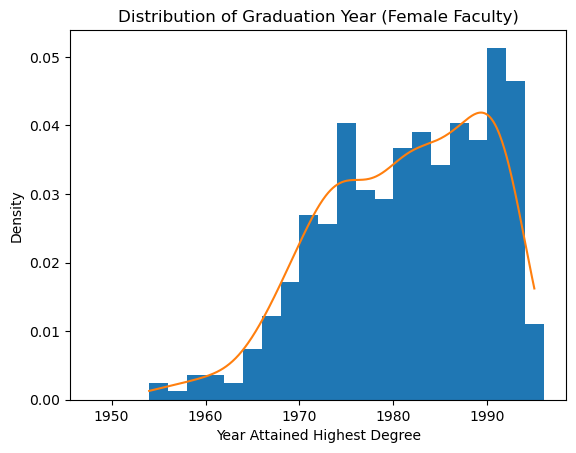

In [36]:

plt.figure()

plt.hist(female, bins=bins, density=True)

kde = gaussian_kde(female)
x_vals = np.linspace(female.min(), female.max(), 500)
plt.plot(x_vals, kde(x_vals))

plt.xlabel("Year Attained Highest Degree")
plt.ylabel("Density")
plt.title("Distribution of Graduation Year (Female Faculty)")

plt.show()


Even though the distribution doesn't exhibit a normal behaviour, we are good to go with Welch.

In [37]:
df1.groupby("sex")["yrdeg"].agg(["count","mean","median","std"])


,count,mean,median,std
sex,,,,
F,409,1981.107579,1982.0,8.700246
M,1188,1974.368687,1973.0,9.643280


/var/folders/4c/hyv6qz1537z47z1zpjs7r47r0000gn/T/ipykernel_8134/1319068063.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male, female], labels=["Male", "Female"])


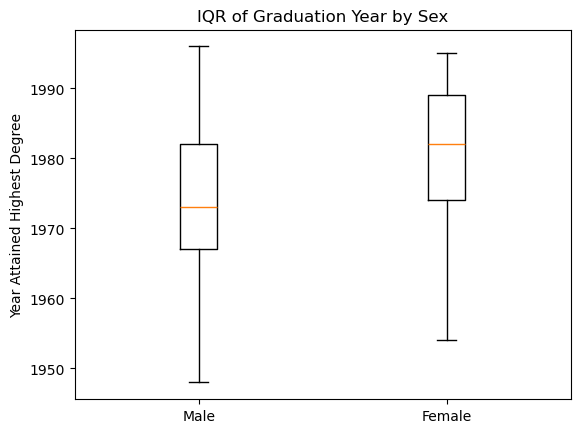

In [38]:
plt.boxplot([male, female], labels=["Male", "Female"])

plt.ylabel("Year Attained Highest Degree")
plt.title("IQR of Graduation Year by Sex")

plt.show()

Let:

$$
\mu_M = \text{mean year of highest degree for male faculty}
$$

$$
\mu_F = \text{mean year of highest degree for female faculty}
$$

And we will be testing:

$$
H_0: \mu_M = \mu_F
$$

$$
H_A: \mu_M \ne \mu_F
$$

In [39]:
t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: -13.131767675682292
p-value: 1.0026508155978013e-35


There is extremely strong statistical evidence that the mean year of degree attainment differs between male and female faculty.
If we think about that from a general perspective then we can explain it by the known fact that there was an overwhelming dominance of males in the academia in the mid 1900s. But over the years the female representation had considerably increased.